In [1]:
from typing import TypedDict, List, Dict
from langgraph.graph import StateGraph, END
import random

In [2]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [3]:
def setup_node(state: AgentState) -> AgentState:
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    state['target_number'] = random.randint(state['lower_bound'], state['upper_bound'])
    state['attempts'] = 0
    state['guesses'] = []
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state

def guess_node(state: AgentState) -> AgentState:
    guess = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(guess)
    state['attempts'] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state

def hint_node(state: AgentState) -> AgentState:
    latest_guess = state['guesses'][-1]
    target = state['target_number']

    if latest_guess < target:
        state['hint'] = f"The number {latest_guess} is too low. Try higher!"
        state['lower_bound'] = latest_guess + 1
        print(f"Hint: {state['hint']}")
    elif latest_guess > target: 
        state['hint'] = f"The number {latest_guess} is too high. Try lower!"
        state['upper_bound'] = latest_guess - 1
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")

    return state

In [4]:
def should_continue(state: AgentState) -> str:

    latest_guess = state['guesses'][-1]
    if latest_guess == state["target_number"]:
        print(f"GAME OVER: Number found!")
        return "end"
    elif state["attempts"] >= 7:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "continue"

In [5]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("hint", hint_node)
graph.add_node("guess", guess_node)

graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    "hint",
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

graph.set_entry_point("setup")
app = graph.compile()

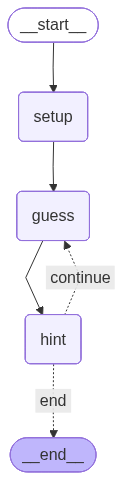

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Student The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 15 (Current range: 1-20)
Hint: The number 15 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 8 (Current range: 1-14)
Hint: The number 8 is too high. Try lower!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 4 (Current range: 1-7)
Hint: The number 4 is too low. Try higher!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 6 (Current range: 5-7)
Hint: The number 6 is too high. Try lower!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 5 (Current range: 5-5)
Success! Correct! You found the number 5 in 5 attempts.
GAME OVER: Number found!
